# Auto-encodeurs débruiteurs avec Keras

## Vérification de l'utilisation de GPU

Allez dans le menu `Exécution > Modifier le type d'execution` et vérifiez que l'on est bien en Python 3 et que l'accélérateur matériel est configuré sur « GPU ».

In [1]:
!nvidia-smi

Thu Oct  8 18:40:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000               On  |   00000000:83:00.0 Off |                  Off |
| 48%   58C    P8             23W /  140W |       1MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import de TensorFlow et des autres librairies nécessaires

In [2]:
import matplotlib.pyplot as plt
import numpy
import tensorflow as tf
import keras

## Chargement de MNIST

Nous allons utiliser un prétraîtement légèrement différent des autres fois : étant donné que nous voulons pouvoir prédire les valeurs données en entrée en sortie (principe de l'auto-encodage), nous allons simplement projeter ces valeurs dans $[0, 1]$ au lieu de $[0, 255]$. Notez qu'habituellement nous ne faisons pas ça : nous normalisons en centrant sur zéro et en divisant par l'écart-type.

In [3]:
(X_train, _), (X_test, y_test) = keras.datasets.mnist.load_data()
nb_classes = 10
input_dim = 28 * 28
X_train = X_train.reshape(-1, input_dim) / 255.0
X_test = X_test.reshape(-1, input_dim) / 255.0

## Application d'un bruit  gaussien

In [4]:
noise_factor = 0.5
X_train_noisy = X_train + numpy.random.normal(0, noise_factor, X_train.shape)
X_test_noisy = X_test + numpy.random.normal(0, noise_factor, X_test.shape)

# On clip les valeurs pour éviter les pixels plus blanc que blanc (ou plus noir
# que noir)
numpy.clip(X_train_noisy, 0, 1, out=X_train_noisy)
numpy.clip(X_test_noisy, 0, 1, out=X_test_noisy)

array([[0.48909503, 0.        , 0.71839535, ..., 0.        , 0.40844258,
        0.        ],
       [0.        , 0.04188285, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.1243033 , 0.26665741, ..., 0.        , 0.36740981,
        0.09231045],
       ...,
       [0.30403752, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.        , 0.        , ..., 0.74275055, 0.03356911,
        0.        ],
       [0.        , 0.        , 0.60807042, ..., 0.15134844, 0.19319032,
        0.61741666]])

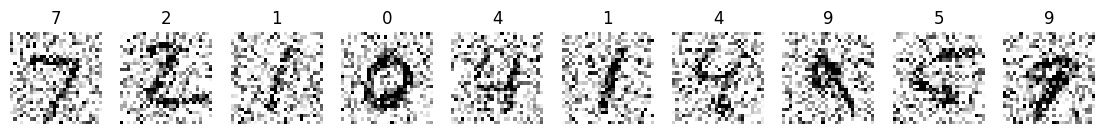

In [5]:
n = 10
f, ax = plt.subplots(1, n, figsize=(n * 1.4, 2))
for i in range(n):
    ax[i].imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax[i].set_title(y_test[i])
    ax[i].axis("off")
plt.show()

## Création de l'autoencodeur débruiteur



In [6]:
encoding_dim = 4

autoencoder = keras.Sequential(
    [keras.layers.Input(shape=(input_dim,)),
     keras.layers.Dense(encoding_dim, activation="leaky_relu"),
     keras.layers.Dense(input_dim, activation="sigmoid")],
    name="autoencoder")
autoencoder.summary()

autoencoder.compile(optimizer="adam", loss="mean_squared_error")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │         3,920 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,060 (27.58 KB)

 Trainable params: 7,060 (27.58 KB)

 Non-trainable params: 0 (0.00 B)

## Apprentissage

In [7]:
autoencoder.fit(X_train_noisy, X_train,
                epochs=50,
                batch_size=256,
                validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0983 - val_loss: 0.0682
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0683 - val_loss: 0.0674
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0671 - val_loss: 0.0653
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0629 - val_loss: 0.0594
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0568 - val_loss: 0.0545
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0538 - val_loss: 0.0531
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0530 - val_loss: 0.0526
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0526 - val_loss: 0.0523
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0523 - val_loss: 0.0520
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0520 - val_loss: 0.0517
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0517 - val_loss: 0.0514
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

## Base de Test

In [8]:
X_test_noisy_pred = autoencoder.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


## Affichage visuel de la performance

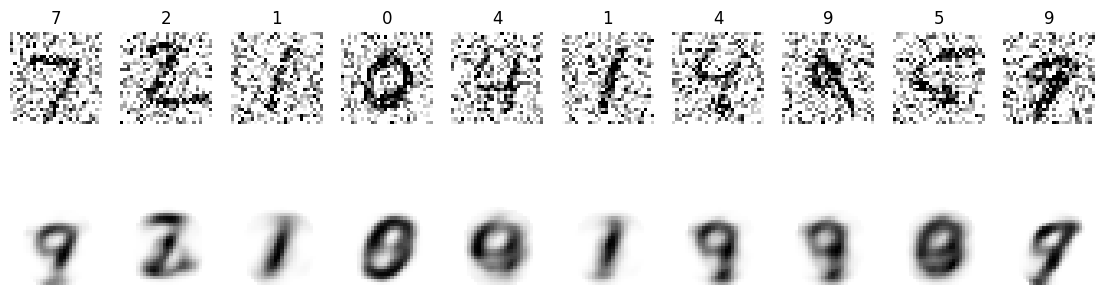

In [9]:
n = 10
_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for i, (ax_top, ax_bottom) in enumerate(ax.T):
    # L'original en haut
    ax_top.imshow(X_test_noisy[i].reshape(28, 28), cmap="gray_r")
    ax_top.set_title(str(y_test[i]))
    ax_top.axis("off")

    # La reconstruction en bas
    ax_bottom.imshow(X_test_noisy_pred[i].reshape(28, 28), cmap="gray_r")
    ax_bottom.axis("off")
plt.show()

## Utilisation des réseaux convolutifs

Pour cela il faut remettre chaque image sous forme 28x28x1. Les CNNs ont besoin de cette 3ème dimension de tenseur (il pourrait y avoir plus de canaux que le niveau de gris : il y en a 3 pour les images en couleur et plus encore dans les couches intermédiaires d'un réseau convolutif où le nombre de canaux en entrée d'une couche sera le nombre de kernels de la couche précédente).

In [10]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train_noisy = X_train_noisy.reshape(-1, 28, 28, 1)
X_test_noisy = X_test_noisy.reshape(-1, 28, 28, 1)

## Création du modèle

On utilisera des séquences de `Conv2D`, `MaxPool2D` avec des kernel de respectivement 3 x 3 et 2 x 2 pour la partie encodeur. Dans ces deux layers, il faudra utiliser l'option `padding="same"` afin d'éviter les effets de bord (l'image étant déjà assez petite comme ça).

Pour la partie décodeur, on utilisera des `Conv2D` de même nature suivis par des `UpSampling2D((2, 2))`, qui correspondent à l'opération inverse de `MaxPool2D`

In [11]:
encoding_dim = 4

autoencoder = keras.Sequential()


def conv(n, activation="leaky_relu"):
  return keras.layers.Conv2D(n, (3, 3), activation=activation, padding="same")


def max_pool():
  return keras.layers.MaxPool2D((2, 2), padding="same")


def up_sampling():
  return keras.layers.UpSampling2D((2, 2))


# Encodage
autoencoder.add(keras.layers.Input(shape=X_train.shape[1:]))
autoencoder.add(conv(32))
autoencoder.add(max_pool())
autoencoder.add(conv(32))
autoencoder.add(max_pool())
autoencoder.add(conv(1))
autoencoder.add(keras.layers.Flatten())
autoencoder.add(keras.layers.Dense(encoding_dim))

# Décodage
autoencoder.add(keras.layers.Dense(49))
autoencoder.add(keras.layers.Reshape((7, 7, 1)))
autoencoder.add(conv(32))
autoencoder.add(up_sampling())
autoencoder.add(conv(32))
autoencoder.add(up_sampling())
autoencoder.add(conv(1, "sigmoid"))

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 1)        │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 49)             │           245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,159 (78.75 KB)

 Trainable params: 20,159 (78.75 KB)

 Non-trainable params: 0 (0.00 B)

## Apprentissage

In [12]:
autoencoder.fit(X_train_noisy, X_train,
                epochs=100,
                batch_size=128,
                validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.2744 - val_loss: 0.2214
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2114 - val_loss: 0.2047
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2015 - val_loss: 0.1994
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1971 - val_loss: 0.1959
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1944 - val_loss: 0.1938
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1925 - val_loss: 0.1913
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1908 - val_loss: 0.1915
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1895 - val_loss: 0.1894
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1885 - val_loss: 0.1882
Epoch 10/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1876 - val_loss: 0.1871
Epoch 11/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1868 - val_loss: 0.1863
Epoch 12/100
375/375 ━━━━━━━━━━━━━━━━━━

## Affichage des performances

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


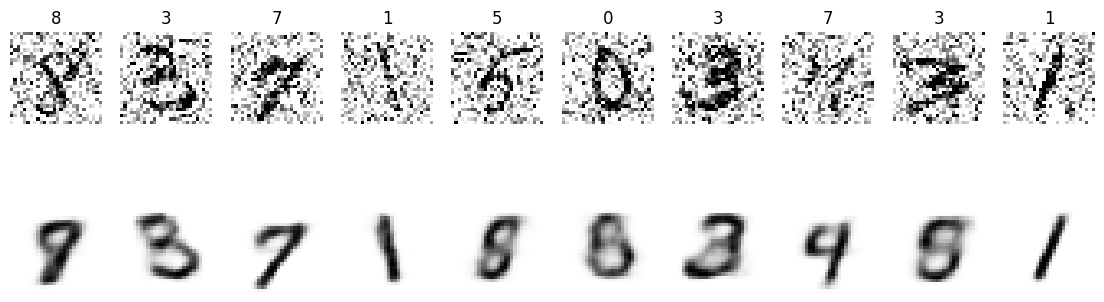

In [13]:
X_test_noisy_pred = autoencoder.predict(X_test_noisy).reshape(-1, 28, 28)

n = 10

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for (ax_top, ax_bottom), random_index in zip(ax.T, random_indexes):
    # L'image originale en haut
    ax_top.set_title(str(y_test[random_index]))
    ax_top.imshow(X_test_noisy[random_index].reshape(28, 28), cmap="gray_r")
    ax_top.axis("off")

    # L'image reconstruite en bas
    ax_bottom.imshow(X_test_noisy_pred[random_index], cmap="gray_r")
    ax_bottom.axis("off")
plt.show()

## Sur des images non-bruitées

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


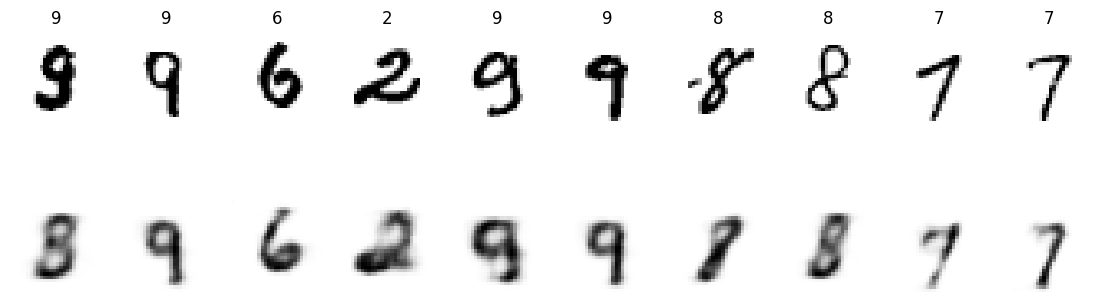

In [14]:
X_test_pred = autoencoder.predict(X_test).reshape(-1, 28, 28)

n = 10

random_indexes = numpy.random.choice(X_test.shape[0],
                                     replace=False,
                                     size=n)

_, ax = plt.subplots(2, n, figsize=(n * 1.4, 4))
for (ax_top, ax_bottom), random_index in zip(ax.T, random_indexes):
    # L'image originale en haut
    ax_top.set_title(str(y_test[random_index]))
    ax_top.imshow(X_test[random_index].reshape(28, 28), cmap="gray_r")
    ax_top.axis("off")

    # L'image reconstruite en bas
    ax_bottom.imshow(X_test_pred[random_index], cmap="gray_r")
    ax_bottom.axis("off")
plt.show()

## Auto-encodeurs variationnels

Pour les VAEs, la méthode d'apprentissage est beaucoup moins facile à mettre en place, en partie à cause de [l'astuce de re-paramétrisation](https://stats.stackexchange.com/questions/199605/how-does-the-reparameterization-trick-for-vaes-work-and-why-is-it-important)). La suggestion des mainteneurs de Keras est d'utiliser le code suivant :

In [15]:
class Sampling(keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [16]:
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = keras.layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(16, activation="relu")(x)
z_mean = keras.layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = keras.layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = keras.layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = keras.layers.Reshape((7, 7, 64))(x)
x = keras.layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = keras.layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = keras.layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [19]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(X_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - kl_loss: 2.4873 - loss: 217.3674 - reconstruction_loss: 214.8801
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 3.2256 - loss: 190.1372 - reconstruction_loss: 186.9115
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 3.3975 - loss: 184.7309 - reconstruction_loss: 181.3333
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.2517 - loss: 170.7548 - reconstruction_loss: 165.5030
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.8920 - loss: 163.7575 - reconstruction_loss: 157.8655
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.0810 - loss: 161.0089 - reconstruction_loss: 154.9278
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.1656 - loss: 159.2997 - reconstruction_loss: 153.1341
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 6.2334 - loss: 158.2129 - reconstruction_loss: 151.9795
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms

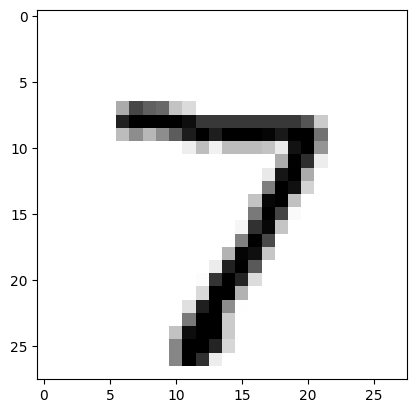

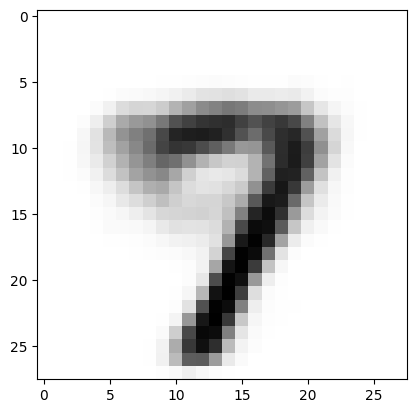

In [20]:
def auto_encode_example(example: numpy.ndarray) -> None:
  x_z_mean, x_z_log_var, x_z = vae.encoder(example[None, ...])
  decoded = vae.decoder(x_z).numpy().squeeze()
  plt.imshow(example.squeeze(), cmap="gray_r")
  plt.show()
  plt.imshow(decoded, cmap="gray_r")
  plt.show()


auto_encode_example(X_test[0])